In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["MKL_CBWR"] = "COMPATIBLE"
os.environ["ATEN_CPU_CAPABILITY"] = "avx2"
os.environ["OMP_NUM_THREADS"] = os.environ["MKL_NUM_THREADS"] = os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["NPY_DISABLE_CPU_FEATURES"] = "AVX512F AVX512CD AVX512_KNL AVX512_KNM AVX512_SKX AVX512_CLX AVX512_CNL AVX512_ICL AVX512_SPR"
os.environ["OPENBLAS_CORETYPE"] = "Haswell"
# JAX (GW solves) and PyTorch (φ/ψ training) share the GPU. Stop JAX from reserving
# most of the card upfront; it allocates as needed, up to 95% for the final GW solve.
# Must be set before JAX is imported.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys
sys.path.append("..")

# Example Alignment on Human Embryo Slices (HESTA)

We align two Stereo-seq sagittal sections of human embryos from HESTA, the Human Embryogenesis Spatiotemporal Transcriptomic Atlas (https://db.cngb.org/hesta/download/).

The available slices are `CS17_E1S8`, `CS17_E1S9` (Carnegie stage 17) and `CS18_E1S3`, `CS18_E1S4` (Carnegie stage 18), each stored as `<slice>_HESTA.h5ad`. **Pick the two slices to compare in the next cell.** The same cell sets `HESTA_DIR`, the folder with the downloaded files. Leave it as `None` to use the `hesta/` subfolder of the MGW data directory (from `get_data_dir()`, as in `mouse_align.ipynb`). Two slices from the same stage give an adjacent-section alignment. A CS17 and a CS18 slice give a spatiotemporal alignment.

The pipeline is the same as `mouse_align.ipynb`: no fused FGW feature information is used, so the alignment treats the data as if it were "multimodal."

In [2]:
# ============================================================
# Choose the two slices to align
# ============================================================
HESTA_SLICES = ["CS17_E1S8", "CS17_E1S9", "CS18_E1S3", "CS18_E1S4"]

SLICE_A = "CS17_E1S8"   # source slice
SLICE_B = "CS18_E1S3"   # target slice

assert SLICE_A in HESTA_SLICES and SLICE_B in HESTA_SLICES, f"choose from {HESTA_SLICES}"
assert SLICE_A != SLICE_B, "choose two different slices"

# Folder holding the <slice>_HESTA.h5ad files (None: <MGW data dir>/hesta)
HESTA_DIR = None   # e.g. "/path/to/hesta_downloads"

In [3]:
# ============================================================
# M-GW: Pairwise Alignment of Human Embryo (HESTA) Slices
# ============================================================

import scanpy as sc
import anndata as ad
import numpy as np, torch, scipy.sparse as sp
from mgw import util, models, plotting, geometry
from mgw import pullback_metric_field, knn_graph
from mgw.gw import solve_gw_ott
import importlib
import matplotlib.pyplot as plt
import os
from mgw.config import get_data_dir

# ----------------------------
# Runtime & device setup
# ----------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_dtype(torch.float64)
print("Device:", device)

# ----------------------------
# Input files & parameters
# ----------------------------
from pathlib import Path

if HESTA_DIR is None:
    HESTA_DIR = get_data_dir() / 'hesta'  # asks on first run, then remembered per machine
HESTA_DIR = Path(HESTA_DIR).expanduser()
print("HESTA data directory:", HESTA_DIR)

slice_ids = [SLICE_A, SLICE_B]
filehandles_hesta_adata = [HESTA_DIR / f"{s}_HESTA.h5ad" for s in slice_ids]
for fh in filehandles_hesta_adata:
    if not fh.exists():
        raise FileNotFoundError(f"{fh} not found. Set HESTA_DIR above, or call "
                                "get_data_dir(reset=True) to change the data directory.")

# Embedding / network parameters
PCA_comp   = 30
knn_k      = 12
geodesic_eps = 0.01

# Whole-embryo sections hold 65k-130k bins, and the GW solve keeps several n x n matrices
# on the GPU (float32: ~0.73 GiB each at 14k bins, ~1.5 GiB at 20k). 20k runs out of
# memory on a 16 GB GPU; lower this further if needed. None keeps every bin.
MAX_OBS = 14_000

gw_params = dict(verbose=True, inner_maxit=3000, outer_maxit=3000,
                 inner_tol=1e-7, outer_tol=1e-7, epsilon=1e-4)

save_dir = HESTA_DIR / "alignments"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 1. Load datasets and prepare
# ============================================================
def load_hesta_slice(fh, slice_id):
    adata = sc.read_h5ad(fh)

    # X is log-normalized; raw counts are in layers['counts']
    adata.X = adata.layers['counts']
    # Coordinates are stored as uint32; cast so differences don't wrap around
    adata.obsm['spatial'] = adata.obsm['spatial'].astype(np.float64)

    adata.obs['slice'] = [slice_id] * adata.shape[0]
    adata.obs_names = [f"{slice_id}_{n}" for n in adata.obs_names]
    print(f"[{slice_id}] {fh.name}: {adata.n_obs} bins x {adata.n_vars} genes")
    return adata

print('Loading AnnData slices...')
adatas = [load_hesta_slice(fh, s) for fh, s in zip(filehandles_hesta_adata, slice_ids)]

# Intersect genes across all slices
common_genes = sorted(set.intersection(*[set(a.var_names) for a in adatas]))
adatas = [a[:, common_genes] for a in adatas]
print(f"Common genes: {len(common_genes)}")

Device: cuda
HESTA data directory: /nas/lnt/ga79jin/MGW/data/hesta
Loading AnnData slices...
[CS17_E1S8] CS17_E1S8_HESTA.h5ad: 66586 bins x 44254 genes
[CS18_E1S3] CS18_E1S3_HESTA.h5ad: 132277 bins x 47028 genes
Common genes: 42565


In [4]:
from mgw import metrics
from mgw import mgw as mgw
from scipy.spatial.distance import cdist

ad1, ad2 = adatas[0], adatas[1]
tp1, tp2 = slice_ids[0], slice_ids[1]

print(f"\n--- Aligning {tp1} → {tp2} ---")

# Normalization, log1p, PCA
joint = ad.concat([ad1, ad2], join='inner')

sc.pp.normalize_total(joint)
sc.pp.log1p(joint)
sc.pp.pca(joint, n_comps=PCA_comp)

# Split back into slices
A = joint[joint.obs['slice'] == tp1].copy()
B = joint[joint.obs['slice'] == tp2].copy()

# ========================================================
# (a) Feature preprocessing (PCA + CCA "feeler")
# ========================================================

pre = mgw.mgw_preprocess(
        A, B,
        PCA_comp=30,
        CCA_comp=3,
        use_cca_feeler=True,
        use_pca_X=True,
        use_pca_Z=True,
        log1p_X=True,
        log1p_Z=True,
        max_obs_A=MAX_OBS,
        max_obs_B=MAX_OBS,
        verbose=True,
        feature_only=False,
        spatial_only=True,
        rep_norm="zscore",
)

# Keep the (possibly subsampled) slices so they match the coupling
A, B = pre["A_"], pre["B_"]
print(f"Bins used: {tp1}={A.n_obs}, {tp2}={B.n_obs}")


--- Aligning CS17_E1S8 → CS18_E1S3 ---
[mgw.pre] PCA/raw shapes: X=(20000, 30)  Z=(20000, 30)
[mgw.pre] CCA feeler: PCA → small GW (fused) → barycentric → CCA
Using precomputed PCA (30 comps).
Using precomputed PCA (30 comps).
Feature shapes -> X: (20000, 30) Z: (20000, 30)
Feeler GW sizes: X-side 8000, Z-side 8000
Solving feeler feature alignment.
Computing CCA Components
CCA dims: 3  (applied to full sets)
Bins used: CS17_E1S8=20000, CS18_E1S3=20000


In [5]:
PCA_component = 30
CCA_component = 3

PHI_ARC = (128,256,256,128)
KNN_K= 12
DEFAULT_GW_PARAMS = dict(verbose=True, inner_maxit=3000, outer_maxit=3000, inner_tol=1e-7,   outer_tol=1e-7,   epsilon=1e-4)
DEFAULT_LR = 1e-3
DEFAULT_EPS = 1e-2
DEFAULT_ITER = 20_000
SEED = 1

In [6]:
EXP_PATH = None #specify the path to save your trained phi psi model (None: retrain without caching)
EXP_TAG = f'HESTA_{SLICE_A}_{SLICE_B}_CCA_seed{SEED}' #specify the name of your experiment

[mgw.core] device=cuda dtype=torch.float64
[mgw.core] dims: E=2, F_M=3, F_N=3
[mgw.core] seed=1
[mgw.core] deterministic training (fused Adam, deterministic kernels)
[mgw.core] training φ, ψ
[train_phi] step=1000 loss=0.300239
[train_phi] step=2000 loss=0.240532
[train_phi] step=3000 loss=0.344369
[train_phi] step=4000 loss=0.348719
[train_phi] step=5000 loss=0.201920
[train_phi] step=6000 loss=0.202980
[train_phi] step=7000 loss=0.187720
[train_phi] step=8000 loss=0.182811
[train_phi] step=9000 loss=0.177553
[train_phi] step=10000 loss=0.173226
[train_phi] step=11000 loss=0.198631
[train_phi] step=12000 loss=0.175392
[train_phi] step=13000 loss=0.164574
[train_phi] step=14000 loss=0.162620
[train_phi] step=15000 loss=0.160637
[train_phi] step=16000 loss=0.167254
[train_phi] step=17000 loss=0.157995
[train_phi] step=18000 loss=0.157053
[train_phi] step=19000 loss=0.156853
[train_phi] step=20000 loss=0.158355
[train_phi] step=1000 loss=0.969421
[train_phi] step=2000 loss=0.959380
[train

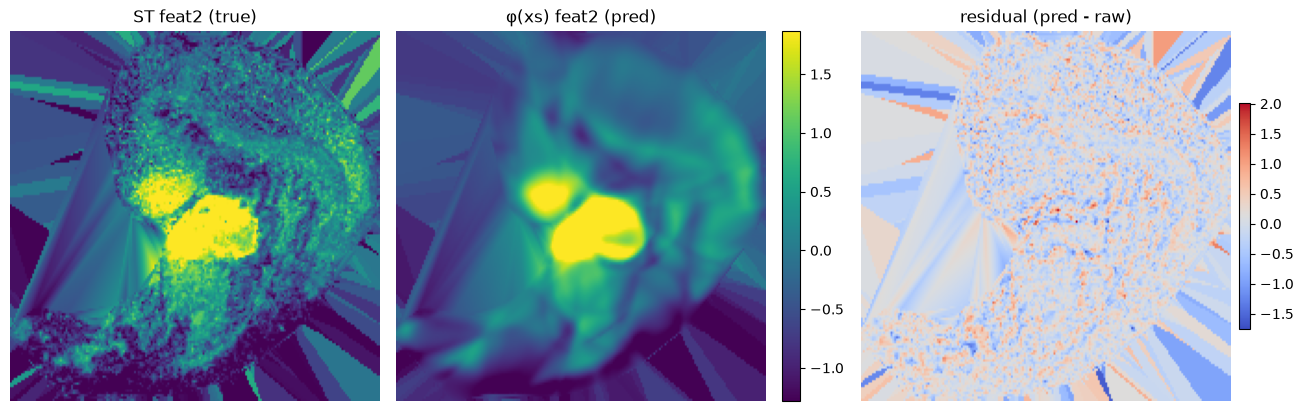

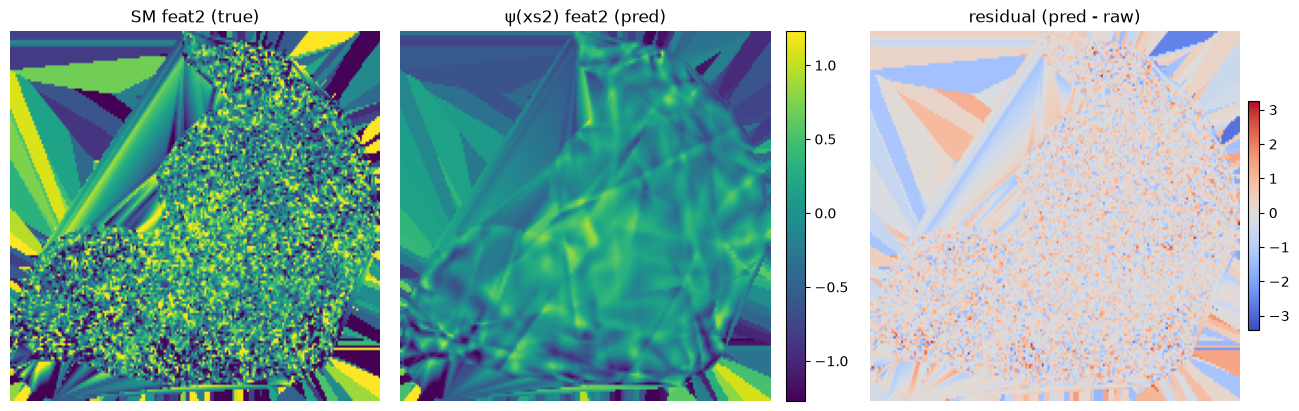

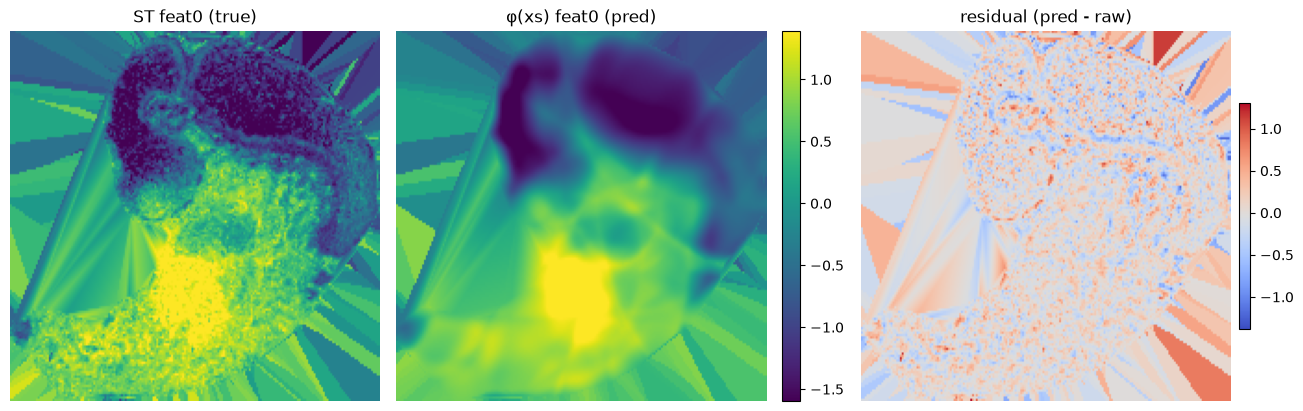

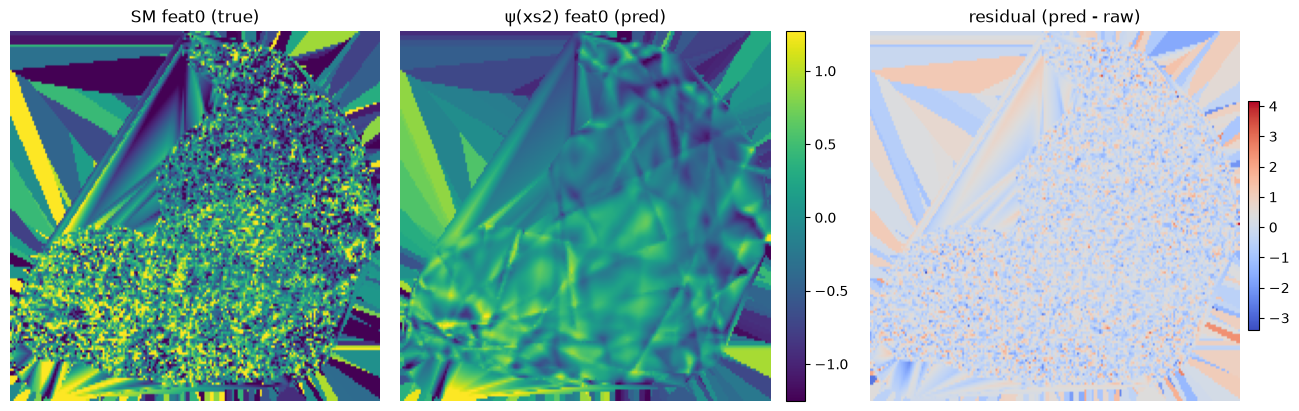

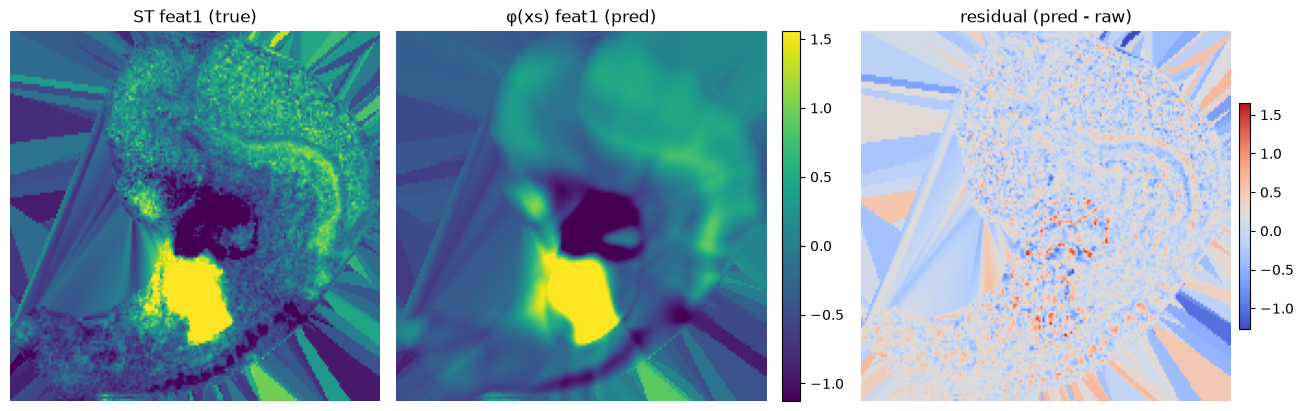

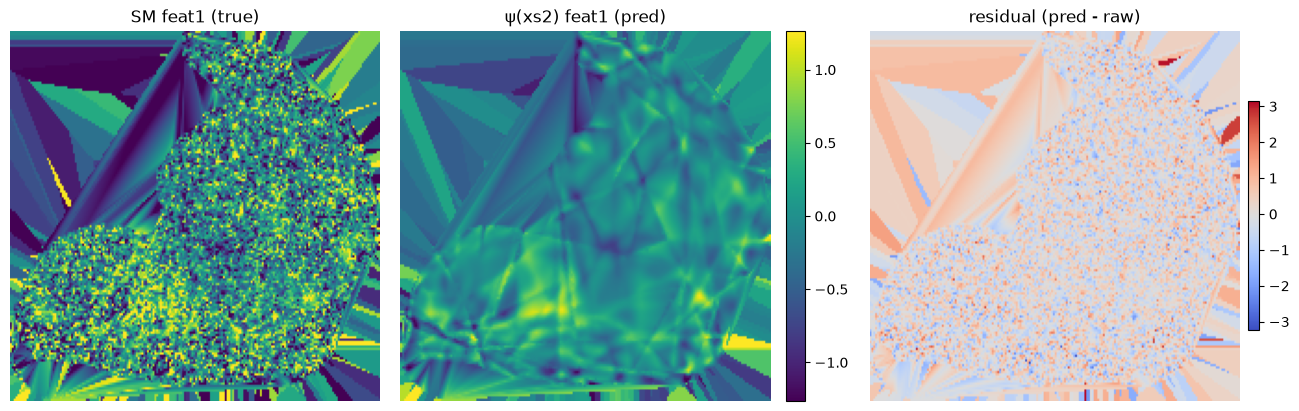

[mgw.core] pullback metrics & geodesics
Rescaling Jacobians by 228.4204207434238.
Rescaling Jacobians by 723.2486078699338.
[mgw.core] cost matrices: d^2 (cost_p=2)
[mgw.core] solving GW with {'verbose': True, 'inner_maxit': 3000, 'outer_maxit': 3000, 'inner_tol': 1e-07, 'outer_tol': 1e-07, 'epsilon': 0.0001}


W1001 18:36:37.876787 2429586 bfc_allocator.cc:371] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.51GiB from the lower end with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1001 18:36:37.876913 2429586 bfc_allocator.cc:371] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.51GiB from the lower end with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1001 18:36:37.877018 2429586 bfc_allocator.cc:371] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.51GiB from the lower end with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1001 18:36:37.877084 2429586 bfc_allocator.cc:371] Allocator (GPU_0_bfc) ran out of memory trying to allocat

JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4.47GiB with allocator GPU_0_bfc on device 0. [tf-allocator-allocation-error=''] [executable_name='jit_multiply']

In [7]:
out = mgw.mgw_align_core(
        pre,
        widths=PHI_ARC,
        lr=DEFAULT_LR,
        niter=DEFAULT_ITER,
        knn_k=KNN_K,
        geodesic_eps=DEFAULT_EPS,
        save_dir=EXP_PATH, 
        tag=EXP_TAG, 
        verbose=True,
        plot_net=True,
        gw_params = DEFAULT_GW_PARAMS,
        seed=SEED,
        deterministic=True,
        n_restarts=1,
    )

# We can plot the associated alignment after rigid-transformation into a common frame with Procrustes.

In [ ]:
xs = out["xs"]
xs2 = out["xs2"]
P = out["P"]
xs_aligned, xt_aligned, R, tvec = plotting.procrustes_from_coupling(xs, xs2, P)
plotting.plot_alignment_lines_dense(xs, xs2, P, alpha=0.01)

# We can check the orientation of the alignment.

In [ ]:
Y = (P @ xs2) / P.sum(1, keepdims=True)
U, _, Vt = np.linalg.svd((xs - xs.mean(0)).T @ (Y - Y.mean(0)))
print(f"orientation det = {np.linalg.det(U @ Vt):+.0f}")

# We can also view the alignment as two tilted layers joined by the coupling's peak links.

In [ ]:
from mgw import align_vis

A_labels = plotting._labels_or_cluster(A, key="celltype")
B_labels = plotting._labels_or_cluster(B, key="celltype")

top, bottom, _ = align_vis.coarsen_to_shared_annotations(A_labels, B_labels, max_classes=7)
_ = align_vis.plot_tilted_alignment(
    A.obsm["spatial"], B.obsm["spatial"], top, bottom, P,
    dataset_title=f"Human embryo {tp1} → {tp2} · MGW", top_name=tp1, bottom_name=tp2,
    label_description="original tissue annotations", k_per_point=3)

# One can also project the annotations through the alignment to find the `mgw` predicted clusters.

In [ ]:
A_pred, A_conf, _ = plotting.project_labels_via_P(P.T, B_labels, direction="A_to_B")
plotting.plot_projected_labels(B.obsm['spatial'], A.obsm['spatial'],
                                  B_labels, A_pred, conf_thresh=0.5, s=10)

# Save the coupling for later analysis.

In [ ]:
np.save(save_dir / f"P_{tp1}_{tp2}.npy", P)
print("Saved", save_dir / f"P_{tp1}_{tp2}.npy")